# Employee Salary Prediction — EDA & Model Comparison

**B.Tech Final Year Project**

This notebook explores the salary dataset and compares three regression
models (Linear Regression, Random Forest, XGBoost) to predict employee
salary based on experience, education, job role, location, and industry.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/salary_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (1500, 6)


,experience,education_level,job_role,location,industry,salary
0,6,Masters,Analyst,Chennai,Retail,598000.0
1,10,Bachelors,Business Analyst,Kolkata,Healthcare,655000.0
2,21,High School,Manager,Hyderabad,Manufacturing,1450000.0
3,11,High School,Analyst,Mumbai,Finance,884000.0
4,15,Bachelors,DevOps Engineer,Pune,Manufacturing,1041000.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       1500 non-null   int64  
 1   education_level  1500 non-null   str    
 2   job_role         1500 non-null   str    
 3   location         1500 non-null   str    
 4   industry         1500 non-null   str    
 5   salary           1500 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 70.4 KB


In [4]:
df.describe()


,experience,salary
count,1500.000000,1.500000e+03
mean,12.463333,1.109029e+06
std,7.507745,4.266234e+05
min,0.000000,3.190000e+05
25%,6.000000,7.897500e+05
50%,12.000000,1.046000e+06
75%,19.000000,1.339250e+06
max,25.000000,3.096000e+06


## 3. Exploratory Data Analysis

### 3.1 Salary Distribution

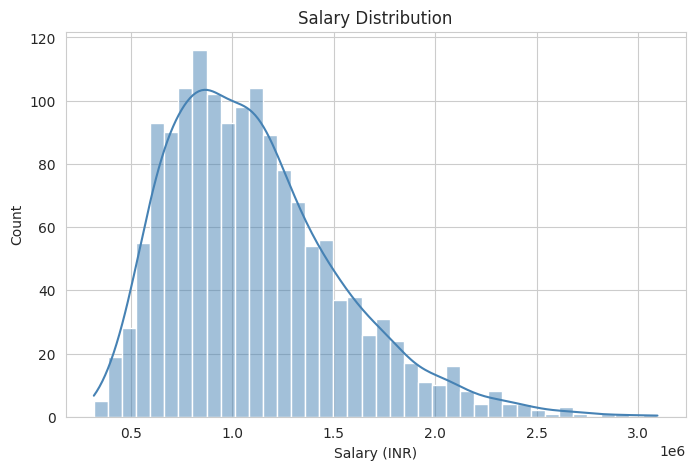

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["salary"], bins=40, kde=True, color="steelblue")
plt.title("Salary Distribution")
plt.xlabel("Salary (INR)")
plt.show()


### 3.2 Salary vs Experience

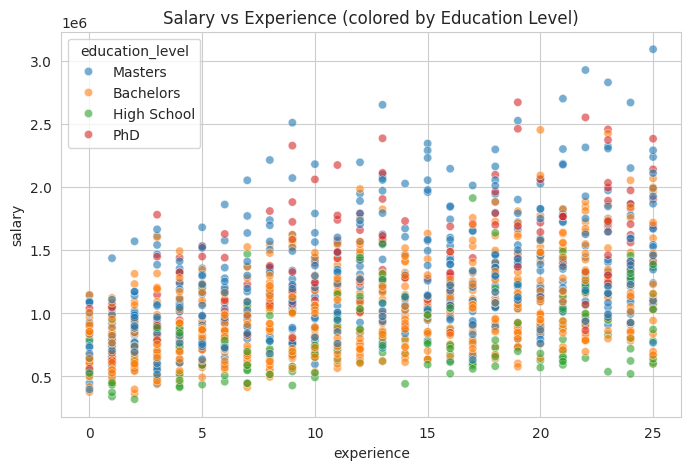

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="experience", y="salary", hue="education_level", alpha=0.6)
plt.title("Salary vs Experience (colored by Education Level)")
plt.show()


### 3.3 Average Salary by Job Role

/tmp/ipykernel_617/1255102581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="job_role", y="salary", order=order, errorbar=None, palette="viridis")


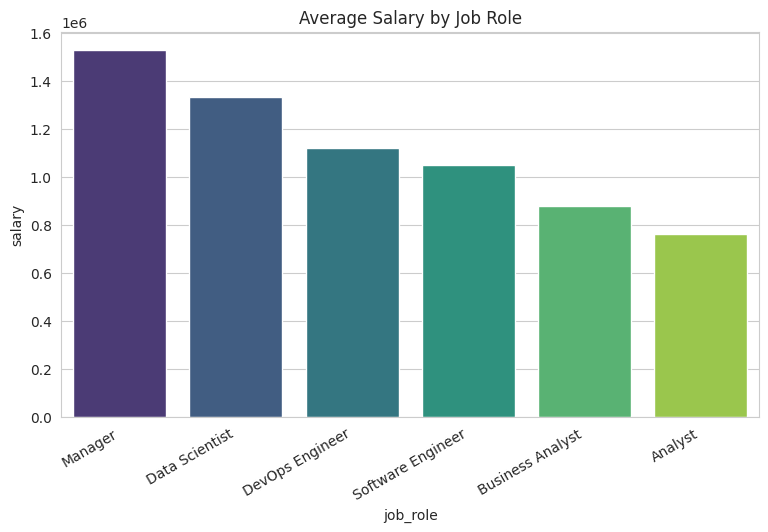

In [7]:
plt.figure(figsize=(9, 5))
order = df.groupby("job_role")["salary"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="job_role", y="salary", order=order, errorbar=None, palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.title("Average Salary by Job Role")
plt.show()


### 3.4 Average Salary by Location & Industry

/tmp/ipykernel_617/4824033.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="location", y="salary", order=loc_order, errorbar=None, ax=axes[0], palette="crest")
/tmp/ipykernel_617/4824033.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="industry", y="salary", order=ind_order, errorbar=None, ax=axes[1], palette="flare")


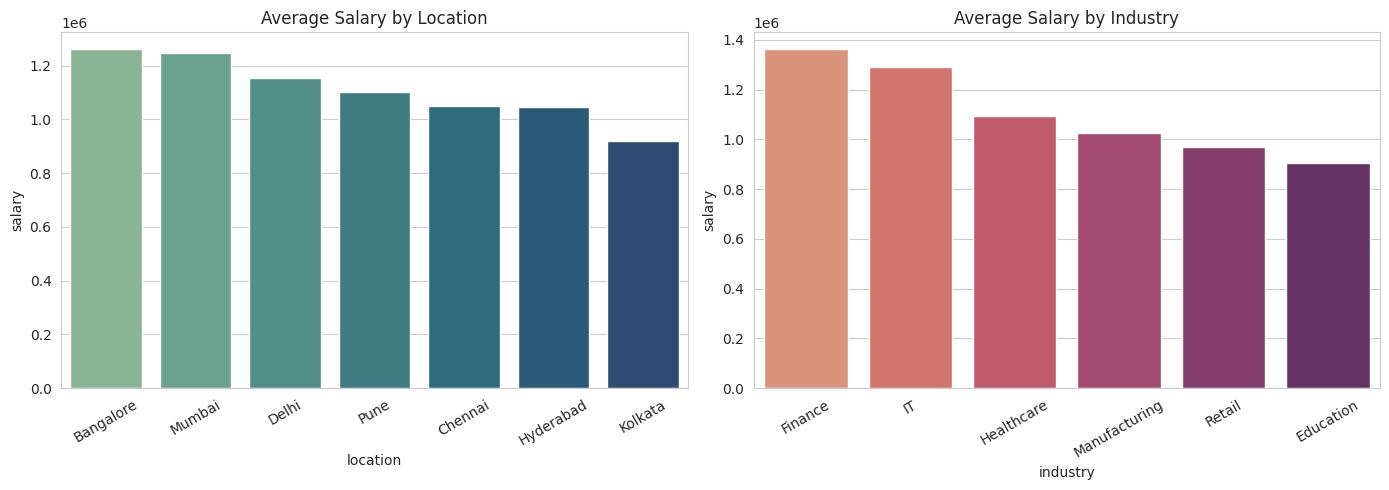

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loc_order = df.groupby("location")["salary"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="location", y="salary", order=loc_order, errorbar=None, ax=axes[0], palette="crest")
axes[0].set_title("Average Salary by Location")
axes[0].tick_params(axis="x", rotation=30)

ind_order = df.groupby("industry")["salary"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="industry", y="salary", order=ind_order, errorbar=None, ax=axes[1], palette="flare")
axes[1].set_title("Average Salary by Industry")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### 3.5 Correlation Heatmap (numeric + one-hot features)

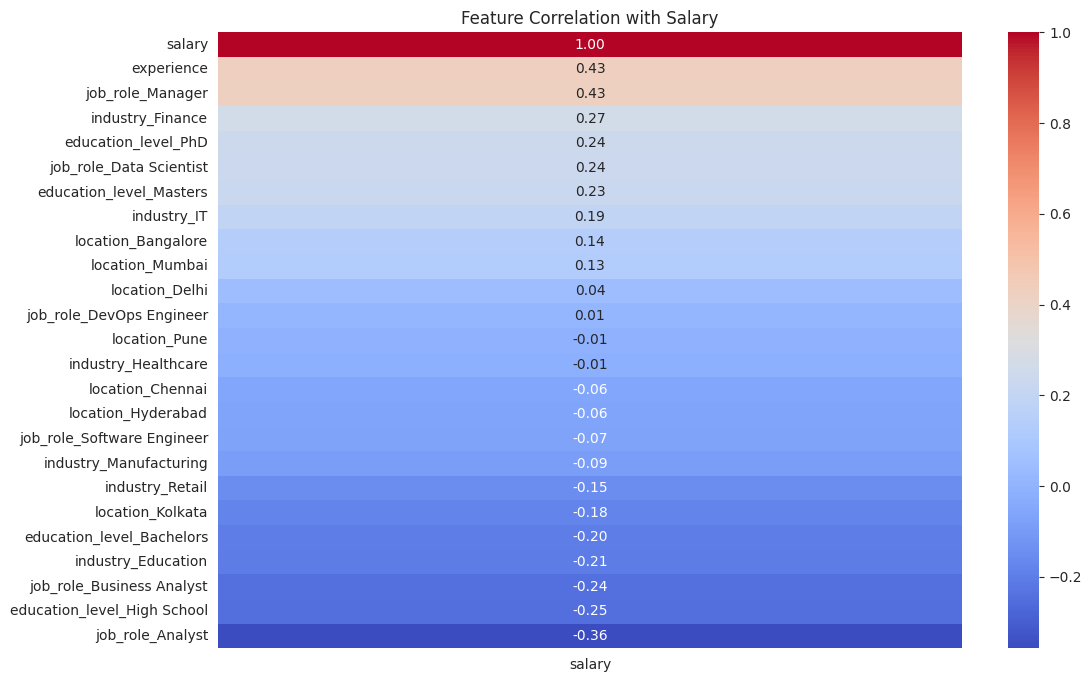

In [9]:
corr_df = pd.get_dummies(df)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr()[["salary"]].sort_values("salary", ascending=False),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation with Salary")
plt.show()


## 4. Feature Engineering

In [10]:
X = pd.get_dummies(df.drop("salary", axis=1))
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1200, 24)  Test shape: (300, 24)


## 5. Model Training & Comparison

In [11]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate("Linear Regression", lr, X_test, y_test))

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", rf, X_test, y_test))

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", xgb, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2 Score
0,XGBoost,86085.123438,115650.104807,0.930194
1,Linear Regression,96260.716018,129315.109269,0.912724
2,Random Forest,135619.779896,180284.389168,0.830366


### 5.1 Visual Comparison of Models

/tmp/ipykernel_617/3685359109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="mako")
/tmp/ipykernel_617/3685359109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[1], palette="rocket")


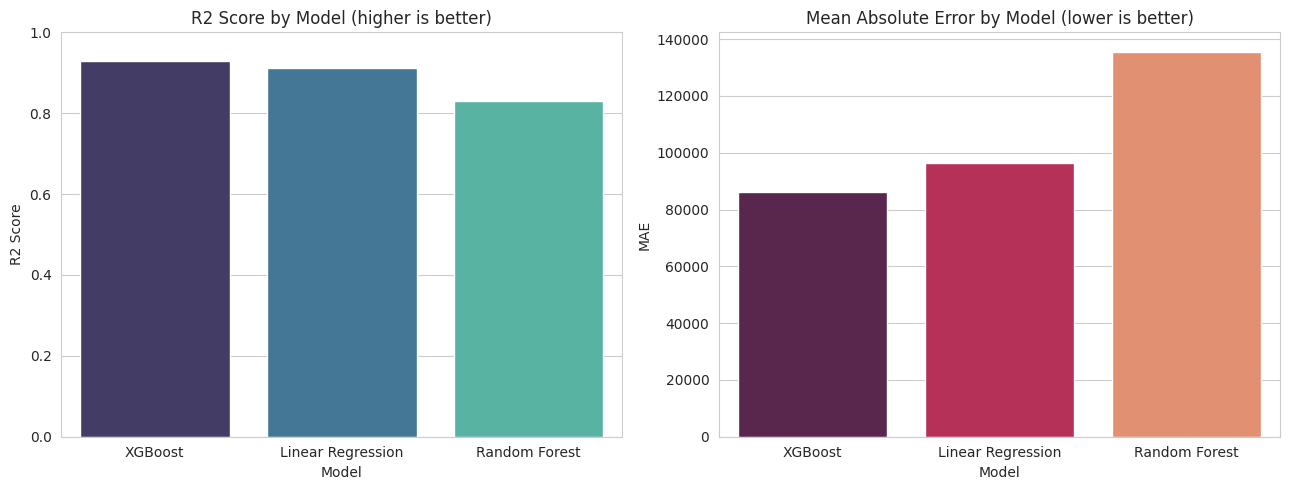

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="mako")
axes[0].set_title("R2 Score by Model (higher is better)")
axes[0].set_ylim(0, 1)

sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[1], palette="rocket")
axes[1].set_title("Mean Absolute Error by Model (lower is better)")

plt.tight_layout()
plt.show()


## 6. Feature Importance (Best Model)

Best model: XGBoost


/tmp/ipykernel_617/1921867663.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


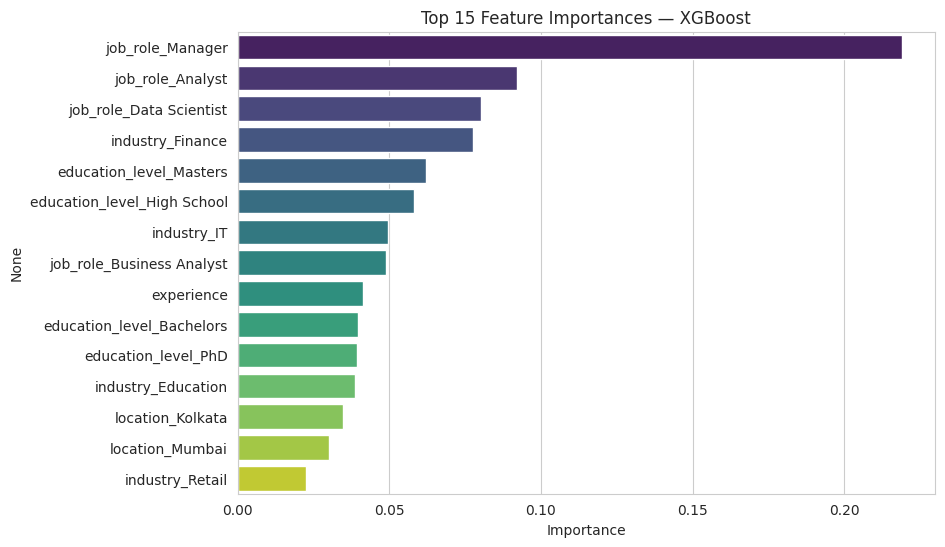

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = {"Linear Regression": lr, "Random Forest": rf, "XGBoost": xgb}[best_model_name]
print("Best model:", best_model_name)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Feature importance not available for this model type.")


## 7. Save Best Model

In [14]:
import joblib

joblib.dump(best_model, "../models/salary_model.pkl")
joblib.dump(list(X.columns), "../models/model_columns.pkl")
joblib.dump(best_model_name, "../models/model_name.pkl")

print(f"Saved '{best_model_name}' as the production model.")


Saved 'XGBoost' as the production model.


## 8. Conclusion

- The dataset shows salary increasing with experience (diminishing returns
  at higher experience levels), and clear premiums for higher education
  levels, certain job roles (Manager, Data Scientist), metro locations
  (Mumbai, Bangalore), and industries (Finance, IT).
- Among the three models compared, the best-performing model (see table
  above) was selected based on R2 score on the held-out test set.
- The saved model (`models/salary_model.pkl`) is used by the Streamlit
  app (`app.py`) for real-time salary prediction.

### Future Improvements
- Use a larger, real-world dataset (e.g. from Kaggle or industry surveys)
- Add more features: company size, skills/certifications, remote vs onsite
- Hyperparameter tuning (GridSearchCV / Optuna)
- Try additional models (LightGBM, CatBoost, Neural Networks)
